## Train a simple convnet on the Fashion MNIST dataset

In this, we will see how to deal with image data and train a convnet for image classification task.

### Load the  `fashion_mnist`  dataset

** Use keras.datasets to load the dataset **

In [13]:
import numpy as np
import tensorflow as tf

In [1]:
from keras.datasets import fashion_mnist
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

Using TensorFlow backend.
/home/siju/.local/lib/python3.6/site-packages/tensorflow/python/framework/dtypes.py:516: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint8 = np.dtype([("qint8", np.int8, 1)])
/home/siju/.local/lib/python3.6/site-packages/tensorflow/python/framework/dtypes.py:517: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_quint8 = np.dtype([("quint8", np.uint8, 1)])
/home/siju/.local/lib/python3.6/site-packages/tensorflow/python/framework/dtypes.py:518: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint16 = np.dtype([("qint16", np.int16, 1)])
/home/siju/.local/lib/python3.6/site-packages/tensorflow/python/framewo

### Find no.of samples are there in training and test datasets

In [7]:
print("Train shape", x_train.shape, y_train.shape)
print("Number of items in training samples = ", x_train.shape[0])

Train shape (60000, 28, 28) (60000,)
Number of items in training samples =  60000


In [6]:
print("Test shape", x_test.shape, y_test.shape)
print("Number of items in testing samples = ", x_test.shape[0])

Test shape (10000, 28, 28) (10000,)
Number of items in testing samples =  10000


In [11]:
np.unique(y_test)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

### Find dimensions of an image in the dataset

In [9]:
#print the shape of first row
print("Dimensions of image = ", x_train[0].shape)

Dimensions of image =  (28, 28)


### Convert train and test labels to one hot vectors

** check `keras.utils.to_categorical()` **

In [20]:
class_names_len = len(np.unique(y_train))
testY = tf.keras.utils.to_categorical(y_test, num_classes=class_names_len)
trainY = tf.keras.utils.to_categorical(y_train, num_classes=class_names_len)

### Normalize both the train and test image data from 0-255 to 0-1

In [16]:
# scale data to the range of [0, 1]
trainX = x_train.astype("float32") / 255.0

In [17]:
testX = x_test.astype("float32") / 255.0

### Reshape the data from 28x28 to 28x28x1 to match input dimensions in Conv2D layer in keras

In [18]:
trainX = trainX.reshape((trainX.shape[0], 28, 28, 1))
testX = testX.reshape((testX.shape[0], 28, 28, 1))

### Import the necessary layers from keras to build the model

### Build a model 

** with 2 Conv layers having `32 3x3 filters` in both convolutions with `relu activations` and `flatten` before passing the feature map into 2 fully connected layers (or Dense Layers) having 128 and 10 neurons with `relu` and `softmax` activations respectively. Now, using `categorical_crossentropy` loss with `adam` optimizer train the model with early stopping `patience=5` and no.of `epochs=10`. **

In [22]:
#Initialize model, reshape & normalize data
model = tf.keras.models.Sequential()

#Add Layers
model.add(tf.keras.layers.Conv2D(32, kernel_size=(3,3), activation='relu'))
model.add(tf.keras.layers.Conv2D(32, kernel_size=(3,3), activation='relu'))
#model.add(tf.keras.layers.MaxPool2D(pool_size=(2,2)))
model.add(tf.keras.layers.Flatten())
model.add(tf.keras.layers.Dense(128, activation='relu'))
#model.add(tf.keras.layers.Dropout(0.25))
model.add(tf.keras.layers.Dense(class_names_len, activation='softmax'))

In [23]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [27]:
patience=5
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_acc',
        patience=patience,
        mode='max',
        verbose=1)
]

In [28]:
epochs=10
batch_size = 400

model.fit(trainX, trainY, validation_data=(testX, testY), batch_size=batch_size, epochs=epochs, callbacks=callbacks)

W0818 14:44:13.031539 140274006222656 deprecation.py:323] From /home/siju/.local/lib/python3.6/site-packages/tensorflow/python/ops/math_grad.py:1250: add_dispatch_support.<locals>.wrapper (from tensorflow.python.ops.array_ops) is deprecated and will be removed in a future version.
Instructions for updating:
Use tf.where in 2.0, which has the same broadcast rule as np.where


Train on 60000 samples, validate on 10000 samples
Epoch 1/10
59600/60000 [============================>.] - ETA: 0s - loss: 0.4856 - accuracy: 0.8304

W0818 14:44:38.535096 140274006222656 callbacks.py:1249] Early stopping conditioned on metric `val_acc` which is not available. Available metrics are: loss,accuracy,val_loss,val_accuracy


60000/60000 [==============================] - 25s 420us/sample - loss: 0.4845 - accuracy: 0.8307 - val_loss: 0.3487 - val_accuracy: 0.8773
Epoch 2/10
59600/60000 [============================>.] - ETA: 0s - loss: 0.3017 - accuracy: 0.8921

W0818 14:45:02.771907 140274006222656 callbacks.py:1249] Early stopping conditioned on metric `val_acc` which is not available. Available metrics are: loss,accuracy,val_loss,val_accuracy


...

60000/60000 [==============================] - 23s 383us/sample - loss: 0.1188 - accuracy: 0.9573 - val_loss: 0.2757 - val_accuracy: 0.9104
Epoch 9/10
59600/60000 [============================>.] - ETA: 0s - loss: 0.1000 - accuracy: 0.9639

W0818 14:47:41.289591 140274006222656 callbacks.py:1249] Early stopping conditioned on metric `val_acc` which is not available. Available metrics are: loss,accuracy,val_loss,val_accuracy


60000/60000 [==============================] - 22s 368us/sample - loss: 0.0999 - accuracy: 0.9639 - val_loss: 0.2732 - val_accuracy: 0.9121
Epoch 10/10
59600/60000 [============================>.] - ETA: 0s - loss: 0.0838 - accuracy: 0.9706

W0818 14:48:04.017560 140274006222656 callbacks.py:1249] Early stopping conditioned on metric `val_acc` which is not available. Available metrics are: loss,accuracy,val_loss,val_accuracy


60000/60000 [==============================] - 23s 379us/sample - loss: 0.0841 - accuracy: 0.9704 - val_loss: 0.2837 - val_accuracy: 0.9124


### Now, to the above model add `max` pooling layer of `filter size 2x2` and `dropout` layer with `p=0.25` after the 2 conv layers and run the model

In [29]:
#Initialize model, reshape & normalize data
model2 = tf.keras.models.Sequential()

#Add Layers
model2.add(tf.keras.layers.Conv2D(32, kernel_size=(3,3), activation='relu'))
model2.add(tf.keras.layers.Conv2D(32, kernel_size=(3,3), activation='relu'))
model2.add(tf.keras.layers.MaxPool2D(pool_size=(2,2)))
model2.add(tf.keras.layers.Flatten())
model2.add(tf.keras.layers.Dense(128, activation='relu'))
model2.add(tf.keras.layers.Dropout(0.25))
model2.add(tf.keras.layers.Dense(class_names_len, activation='softmax'))

In [32]:
model2.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [33]:
epochs=10
batch_size = 400

model2.fit(trainX, trainY, validation_data=(testX, testY), batch_size=batch_size, epochs=epochs, callbacks=callbacks)

Train on 60000 samples, validate on 10000 samples
Epoch 1/10
59600/60000 [============================>.] - ETA: 0s - loss: 0.6109 - accuracy: 0.7829

W0818 14:49:06.925536 140274006222656 callbacks.py:1249] Early stopping conditioned on metric `val_acc` which is not available. Available metrics are: loss,accuracy,val_loss,val_accuracy


60000/60000 [==============================] - 22s 367us/sample - loss: 0.6093 - accuracy: 0.7834 - val_loss: 0.4148 - val_accuracy: 0.8480
Epoch 2/10
59600/60000 [============================>.] - ETA: 0s - loss: 0.3585 - accuracy: 0.8710

W0818 14:49:30.200475 140274006222656 callbacks.py:1249] Early stopping conditioned on metric `val_acc` which is not available. Available metrics are: loss,accuracy,val_loss,val_accuracy


60000/60000 [==============================] - 23s 388us/sample - loss: 0.3579 - accuracy: 0.8713 - val_loss: 0.3259 - val_accuracy: 0.8836
Epoch 3/10
59600/60000 [============================>.] - ETA: 0s - loss: 0.3002 - accuracy: 0.8915

...

60000/60000 [==============================] - 22s 367us/sample - loss: 0.1905 - accuracy: 0.9306 - val_loss: 0.2349 - val_accuracy: 0.9150
Epoch 9/10
59600/60000 [============================>.] - ETA: 0s - loss: 0.1782 - accuracy: 0.9337

W0818 14:52:05.085401 140274006222656 callbacks.py:1249] Early stopping conditioned on metric `val_acc` which is not available. Available metrics are: loss,accuracy,val_loss,val_accuracy


60000/60000 [==============================] - 22s 367us/sample - loss: 0.1782 - accuracy: 0.9338 - val_loss: 0.2341 - val_accuracy: 0.9150
Epoch 10/10
59600/60000 [============================>.] - ETA: 0s - loss: 0.1635 - accuracy: 0.9400

W0818 14:52:27.374818 140274006222656 callbacks.py:1249] Early stopping conditioned on metric `val_acc` which is not available. Available metrics are: loss,accuracy,val_loss,val_accuracy


60000/60000 [==============================] - 22s 371us/sample - loss: 0.1636 - accuracy: 0.9399 - val_loss: 0.2316 - val_accuracy: 0.9189


### Now, to the above model, lets add Data Augmentation 

### Import the ImageDataGenrator from keras and fit the training images

In [40]:
#datagen = tf.keras.preprocessing.image.ImageDataGenerator()

datagen = tf.keras.preprocessing.image.ImageDataGenerator(horizontal_flip=True,
                                                               width_shift_range=0.2,
                                                               height_shift_range=0.2,
                                                               rotation_range=30,
                                                               shear_range=0.2,
                                                               zoom_range=0.3)

#### Showing 5 versions of the first image in training dataset using image datagenerator.flow()

In [38]:
from matplotlib import pyplot as plt
%matplotlib inline  

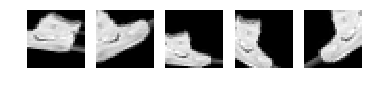

In [42]:
gen = datagen.flow(trainX[0:1], batch_size=1)
for i in range(1, 6):
    plt.subplot(1,5,i)
    plt.axis("off")
    plt.imshow(gen.next().squeeze(), cmap='gray')
    plt.plot()
plt.show()

### Run the above model using fit_generator()

In [45]:
test_gen = tf.keras.preprocessing.image.ImageDataGenerator()

In [46]:
train_generator = datagen.flow(trainX, trainY, batch_size=64)
test_generator = test_gen.flow(testX, testY, batch_size=64)

In [51]:
epochs=10
batch_size = 400

H = model2.fit_generator(train_generator, validation_data=test_generator, epochs=epochs, callbacks=callbacks)

Epoch 1/10
936/938 [============================>.] - ETA: 0s - loss: 0.5692 - accuracy: 0.7915

W0818 15:18:23.592174 140274006222656 callbacks.py:1249] Early stopping conditioned on metric `val_acc` which is not available. Available metrics are: loss,accuracy,val_loss,val_accuracy


938/938 [==============================] - 25s 27ms/step - loss: 0.5692 - accuracy: 0.7914 - val_loss: 0.5799 - val_accuracy: 0.8000
Epoch 2/10
935/938 [============================>.] - ETA: 0s - loss: 0.5688 - accuracy: 0.7917

W0818 15:18:49.694872 140274006222656 callbacks.py:1249] Early stopping conditioned on metric `val_acc` which is not available. Available metrics are: loss,accuracy,val_loss,val_accuracy


938/938 [==============================] - 26s 28ms/step - loss: 0.5689 - accuracy: 0.7917 - val_loss: 0.6381 - val_accuracy: 0.7891
Epoch 3/10
936/938 [============================>.] - ETA: 0s - loss: 0.5608 - accuracy: 0.7935

...

938/938 [==============================] - 27s 28ms/step - loss: 0.5307 - accuracy: 0.8070 - val_loss: 0.5987 - val_accuracy: 0.7937
Epoch 9/10
937/938 [============================>.] - ETA: 0s - loss: 0.5290 - accuracy: 0.8076

W0818 15:21:55.765250 140274006222656 callbacks.py:1249] Early stopping conditioned on metric `val_acc` which is not available. Available metrics are: loss,accuracy,val_loss,val_accuracy


938/938 [==============================] - 27s 28ms/step - loss: 0.5288 - accuracy: 0.8077 - val_loss: 0.6827 - val_accuracy: 0.7815
Epoch 10/10
937/938 [============================>.] - ETA: 0s - loss: 0.5244 - accuracy: 0.8081

W0818 15:22:23.202760 140274006222656 callbacks.py:1249] Early stopping conditioned on metric `val_acc` which is not available. Available metrics are: loss,accuracy,val_loss,val_accuracy


938/938 [==============================] - 27s 29ms/step - loss: 0.5243 - accuracy: 0.8081 - val_loss: 0.6175 - val_accuracy: 0.7974


In [49]:
model2.fit_generator(train_generator, steps_per_epoch=60000//64, epochs=10, 
                    validation_data=test_generator, validation_steps=10000//64)

Epoch 1/10
937/937 [==============================] - 25s 27ms/step - loss: 0.8489 - accuracy: 0.6839 - val_loss: 0.5072 - val_accuracy: 0.8142
Epoch 2/10
937/937 [==============================] - 28s 30ms/step - loss: 0.7566 - accuracy: 0.7186 - val_loss: 0.5858 - val_accuracy: 0.7777
Epoch 3/10
937/937 [==============================] - 25s 27ms/step - loss: 0.7071 - accuracy: 0.7372 - val_loss: 0.5110 - val_accuracy: 0.8148
Epoch 4/10
937/937 [==============================] - 25s 27ms/step - loss: 0.6733 - accuracy: 0.7491 - val_loss: 0.5856 - val_accuracy: 0.8006
Epoch 5/10
937/937 [==============================] - 25s 27ms/step - loss: 0.6461 - accuracy: 0.7609 - val_loss: 0.6267 - val_accuracy: 0.7843
Epoch 6/10
937/937 [==============================] - 25s 27ms/step - loss: 0.6286 - accuracy: 0.7670 - val_loss: 0.5259 - val_accuracy: 0.8159
Epoch 7/10
937/937 [==============================] - 26s 28ms/step - loss: 0.6138 - accuracy: 0.7743 - val_loss: 0.5633 - val_accuracy:

###  Report the final train and validation accuracy

In [61]:
Train_accuracy = model2.evaluate(train_generator)
#Test Accuracy = 

938/938 [==============================] - 13s 14ms/step - loss: 0.4790 - accuracy: 0.8213


In [69]:
print("Train Loss = ", Train_accuracy[0], " Accuracy = ", Train_accuracy[1])

Train Loss =  0.47903300645445457  Accuracy =  0.82135


In [63]:
Test_accuracy = model2.evaluate(test_generator)

157/157 [==============================] - 1s 7ms/step - loss: 0.6175 - accuracy: 0.7974


In [73]:
print("Validation Accuracy = ", Test_accuracy[1])

Validation Accuracy =  0.7974


## **DATA AUGMENTATION ON CIFAR10 DATASET**

One of the best ways to improve the performance of a Deep Learning model is to add more data to the training set. Aside from gathering more instances from the wild that are representative of the distinction task, we want to develop a set of methods that enhance the data we already have. There are many ways to augment existing datasets and produce more robust models. In the image domain, these are done to utilize the full power of the convolutional neural network, which is able to capture translational invariance. This translational invariance is what makes image recognition such a difficult task in the first place. You want the dataset to be representative of the many different positions, angles, lightings, and miscellaneous distortions that are of interest to the vision task.

### **Import neessary libraries for data augmentation**

In [56]:
import tensorflow as tf
import numpy as np                                
import matplotlib.pyplot as plt
import keras as k
from keras.datasets import cifar10
from keras.preprocessing.image import ImageDataGenerator

### **Load CIFAR10 dataset**

170500096/170498071 [==============================] - 17s 0us/step


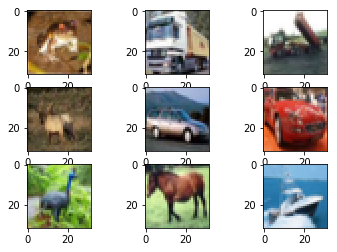

In [54]:
#load data
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
img_rows, img_cols , channels= 32,32,3
for i in range(0,9):
    plt.subplot(330 + 1 + i)
    plt.imshow(x_train[i])
plt.show()

### **Create a data_gen funtion to genererator with image rotation,shifting image horizontally and vertically with random flip horizontally.**

In [57]:
# set up image augmentation
datagen = ImageDataGenerator(
    rotation_range=15,
    horizontal_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1
    #zoom_range=0.3
    )

### **Prepare/fit the generator.**

In [ ]:
datagen.fit(x_train)

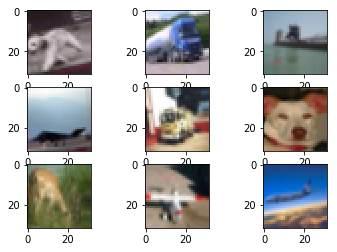

In [58]:
# see example augmentation images
for X_batch, y_batch in datagen.flow(x_train, y_train, batch_size=9):
    for i in range(0, 9):
        plt.subplot(330 + 1 + i)
        plt.imshow(X_batch[i].astype(np.uint8))
    plt.show()
    break

### **Generate 5 images for 1 of the image of CIFAR10 train dataset.**

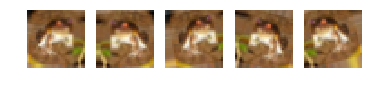

In [82]:
#print for first image

gen = datagen.flow(x_train[0:1], batch_size=1)
for i in range(1, 6):
    plt.subplot(1,5,i)
    plt.axis("off")
    plt.imshow(gen.next().astype(np.uint8).squeeze())
    plt.plot()
plt.show()

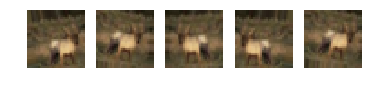

In [83]:
#print for second image
gen = datagen.flow(x_train[3:4], batch_size=1)
for i in range(1, 6):
    plt.subplot(1,5,i)
    plt.axis("off")
    plt.imshow(gen.next().astype(np.uint8).squeeze())
    plt.plot()
plt.show()